In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [7]:
df = pd.read_csv("winequality-red.csv", sep=";")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


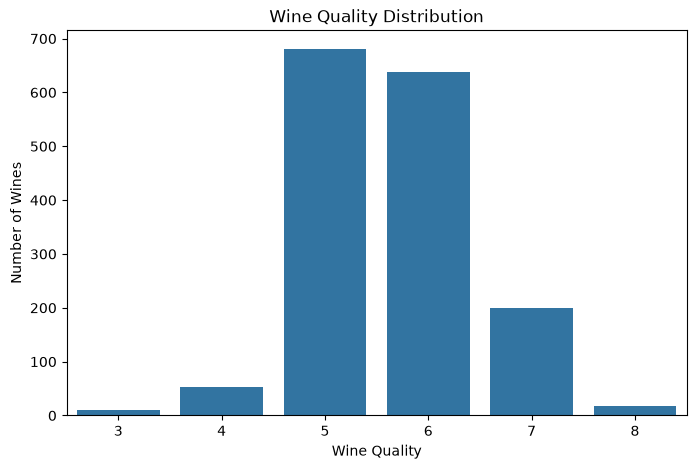

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="quality")

plt.title("Wine Quality Distribution")
plt.xlabel("Wine Quality")
plt.ylabel("Number of Wines")

plt.show()

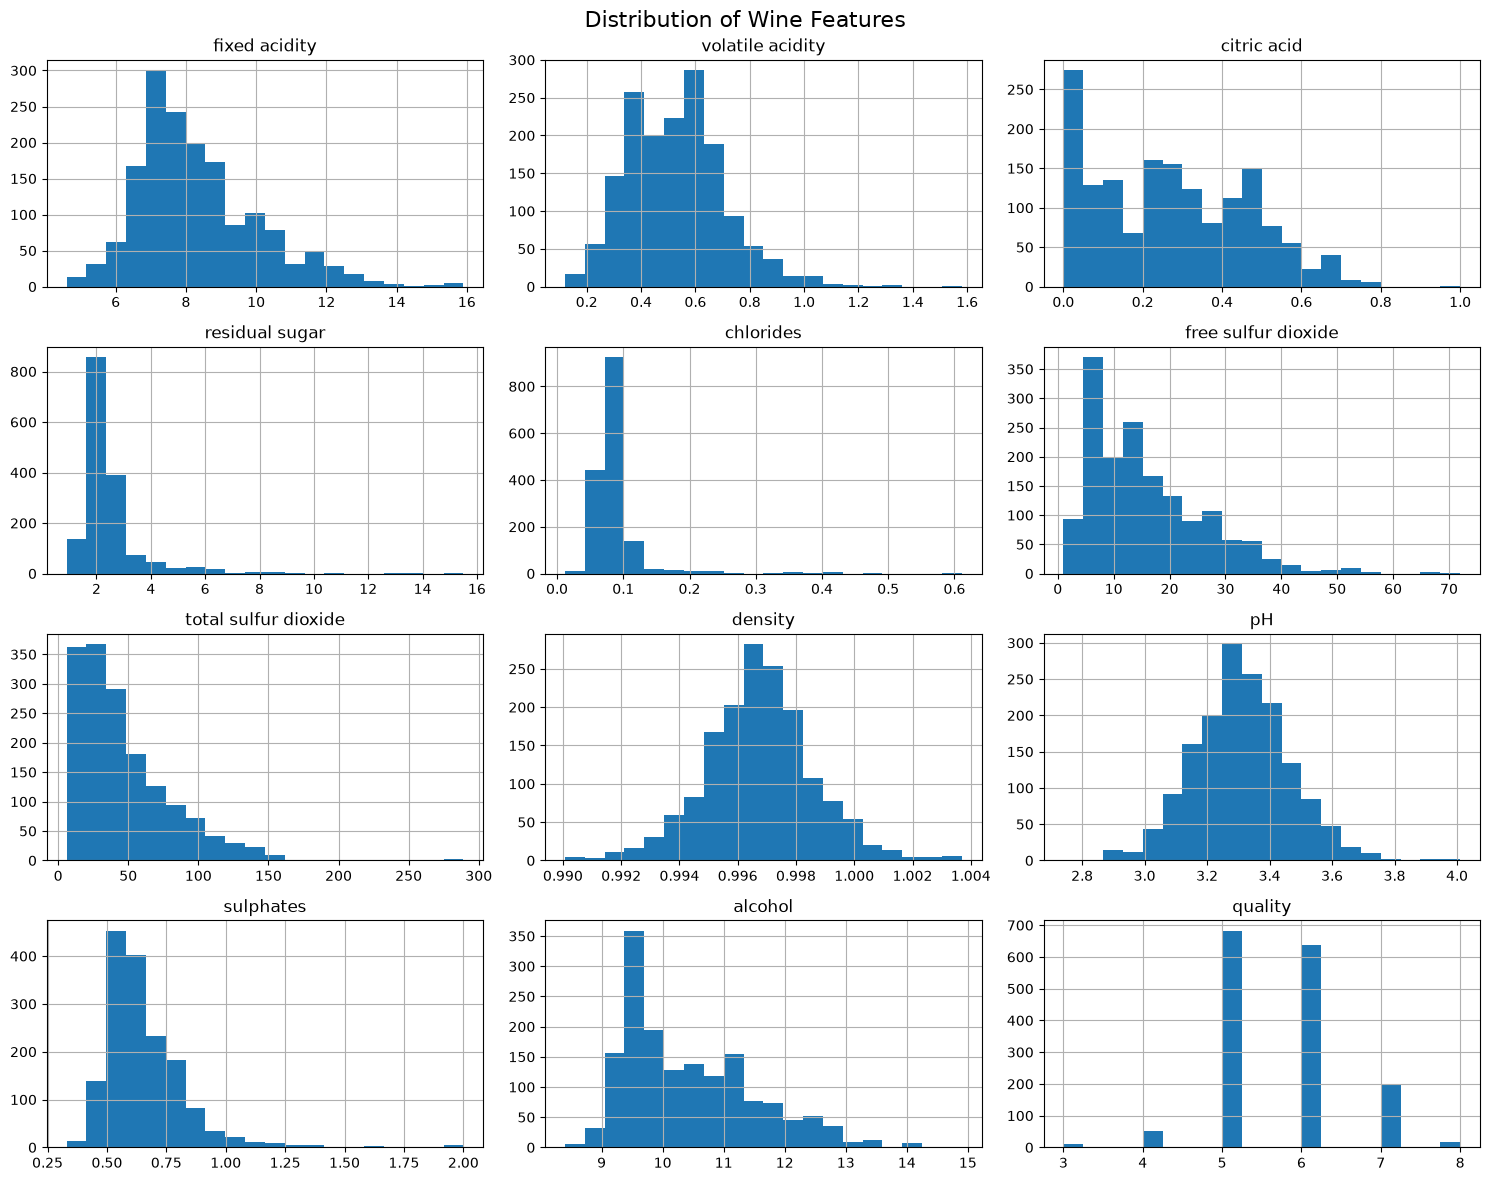

In [10]:
df.hist(figsize=(15, 12), bins=20)

plt.suptitle("Distribution of Wine Features", fontsize=16)
plt.tight_layout()
plt.show()

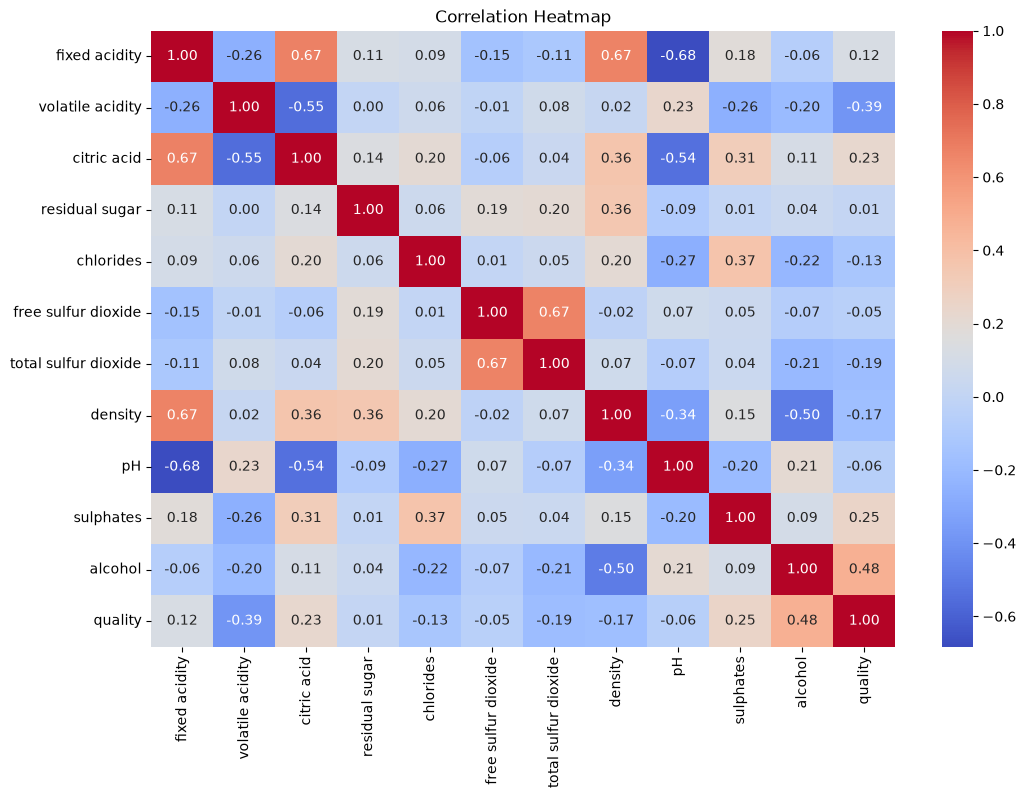

In [11]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [14]:
df["quality_label"] = np.where(
    df["quality"] >= 6,
    1,
    0
)

df["quality_label"].value_counts()

quality_label
1    855
0    744
Name: count, dtype: int64

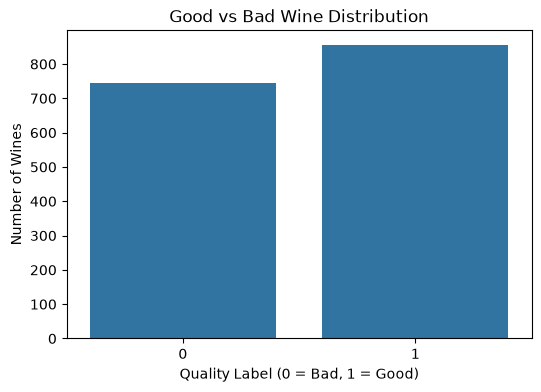

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="quality_label")
plt.title("Good vs Bad Wine Distribution")
plt.xlabel("Quality Label (0 = Bad, 1 = Good)")
plt.ylabel("Number of Wines")
plt.show()

In [17]:
X = df.drop(columns=["quality", "quality_label"])
y = df["quality_label"]

print("Features:", X.columns.tolist())
print("Target: quality_label")

Features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Target: quality_label


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1279, 11)
Testing data: (320, 11)


In [19]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [20]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.815625


In [21]:
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.82      0.81       149
           1       0.84      0.81      0.82       171

    accuracy                           0.82       320
   macro avg       0.81      0.82      0.82       320
weighted avg       0.82      0.82      0.82       320



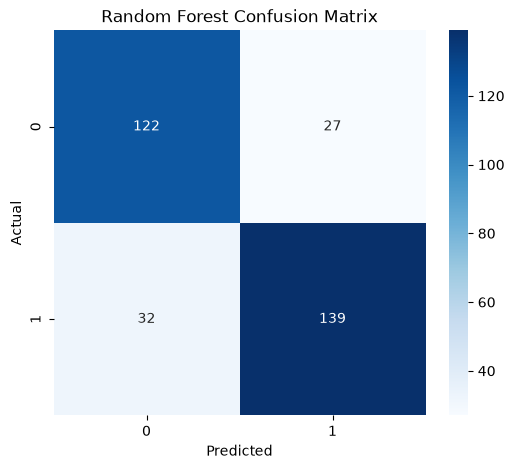

In [22]:
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [23]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
10,alcohol,0.178138
9,sulphates,0.138765
1,volatile acidity,0.113982
6,total sulfur dioxide,0.098226
7,density,0.090872
4,chlorides,0.070574
0,fixed acidity,0.068242
8,pH,0.066011
2,citric acid,0.061240
5,free sulfur dioxide,0.058907


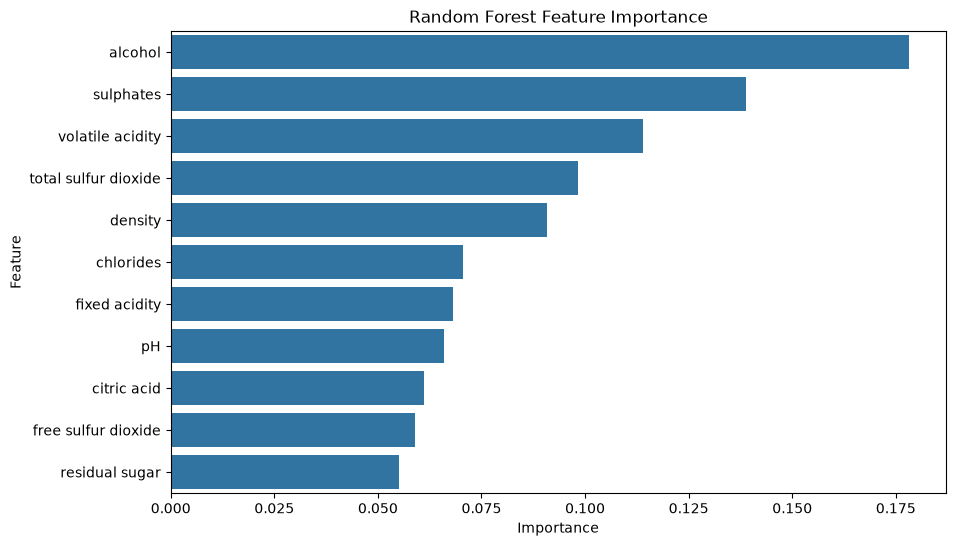

In [24]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [25]:
sgd_model = SGDClassifier(
    random_state=42,
    max_iter=1000,
    tol=1e-3
)

sgd_model.fit(X_train_scaled, y_train)

sgd_pred = sgd_model.predict(X_test_scaled)

sgd_accuracy = accuracy_score(y_test, sgd_pred)

print("SGD Classifier Accuracy:", sgd_accuracy)

SGD Classifier Accuracy: 0.65625


In [26]:
print("SGD Classification Report:")
print(classification_report(y_test, sgd_pred))

SGD Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.56      0.60       149
           1       0.66      0.74      0.70       171

    accuracy                           0.66       320
   macro avg       0.66      0.65      0.65       320
weighted avg       0.66      0.66      0.65       320



In [27]:
svc_model = SVC(
    kernel="rbf",
    random_state=42
)

svc_model.fit(X_train_scaled, y_train)

svc_pred = svc_model.predict(X_test_scaled)

svc_accuracy = accuracy_score(y_test, svc_pred)

print("SVC Accuracy:", svc_accuracy)

SVC Accuracy: 0.7625


In [28]:
print("SVC Classification Report:")
print(classification_report(y_test, svc_pred))

SVC Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.81      0.76       149
           1       0.81      0.72      0.76       171

    accuracy                           0.76       320
   macro avg       0.77      0.77      0.76       320
weighted avg       0.77      0.76      0.76       320



In [29]:
print("SVC Classification Report:")
print(classification_report(y_test, svc_pred))

SVC Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.81      0.76       149
           1       0.81      0.72      0.76       171

    accuracy                           0.76       320
   macro avg       0.77      0.77      0.76       320
weighted avg       0.77      0.76      0.76       320



In [30]:
print("SVC Classification Report:")
print(classification_report(y_test, svc_pred))

SVC Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.81      0.76       149
           1       0.81      0.72      0.76       171

    accuracy                           0.76       320
   macro avg       0.77      0.77      0.76       320
weighted avg       0.77      0.76      0.76       320



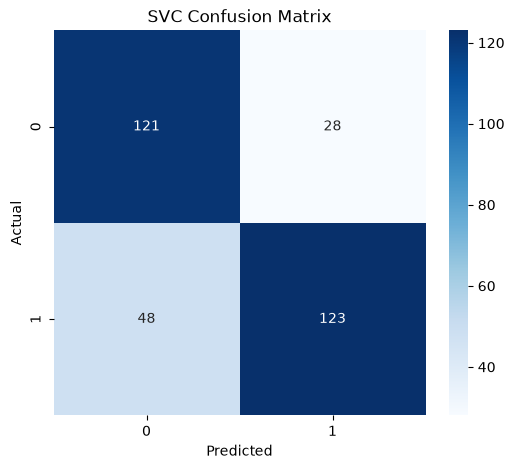

In [31]:
cm_svc = confusion_matrix(y_test, svc_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_svc,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("SVC Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [32]:

results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "SGD Classifier",
        "SVC"
    ],
    "Accuracy": [
        rf_accuracy,
        sgd_accuracy,
        svc_accuracy
    ]
})

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

results

,Model,Accuracy
0,Random Forest,0.815625
2,SVC,0.762500
1,SGD Classifier,0.656250


In [33]:
print("Model Comparison:")
print(results)

best_model = results.iloc[0]["Model"]
best_accuracy = results.iloc[0]["Accuracy"]

print("\nBest Performing Model:", best_model)
print("Accuracy:", round(best_accuracy * 100, 2), "%")

print("\nConclusion:")
print(
    f"{best_model} achieved the highest accuracy among the three tested models. "
    "Based on the model comparison, classification report, and confusion matrix, "
    "this model can be considered suitable for predicting wine quality labels."
)

Model Comparison:
            Model  Accuracy
0   Random Forest  0.815625
2             SVC  0.762500
1  SGD Classifier  0.656250

Best Performing Model: Random Forest
Accuracy: 81.56 %

Conclusion:
Random Forest achieved the highest accuracy among the three tested models. Based on the model comparison, classification report, and confusion matrix, this model can be considered suitable for predicting wine quality labels.


## Conclusion

In this project, different machine learning classification models were trained to predict wine quality as Good or Bad based on physicochemical properties.

Random Forest, SGD Classifier, and SVC were trained and evaluated using accuracy, classification reports, and confusion matrices.

The models were compared based on their performance. The model with the highest accuracy provided the best classification performance on the test dataset.

Overall, this project demonstrates how machine learning can be applied to wine quality prediction using chemical properties of wine.